In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load the dataset
df = pd.read_excel('Reference/TFR.xlsx', skiprows=2, nrows=2, index_col=0)
df = df.T
df.index = df.index.astype(int)

In [4]:
# Reshape into 2D input
X = np.array(df.index).reshape(-1, 1)
y_birth = df['Number of Birth']
y_tfr = df['Total Fertility Rate']

In [5]:
# Polynomial Regression
degree = 3  # You can experiment with different degrees
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

In [6]:
# Fit polynomial regression models
model_birth_poly = LinearRegression()
model_birth_poly.fit(X_poly, y_birth)
model_tfr_poly = LinearRegression()
model_tfr_poly.fit(X_poly, y_tfr)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# Predict future values
future_years = np.array(range(df.index.max() + 1, df.index.max() + 11)).reshape(-1, 1)
future_years_poly = poly.transform(future_years)
predicted_births_poly = model_birth_poly.predict(future_years_poly)
predicted_tfr_poly = model_tfr_poly.predict(future_years_poly)

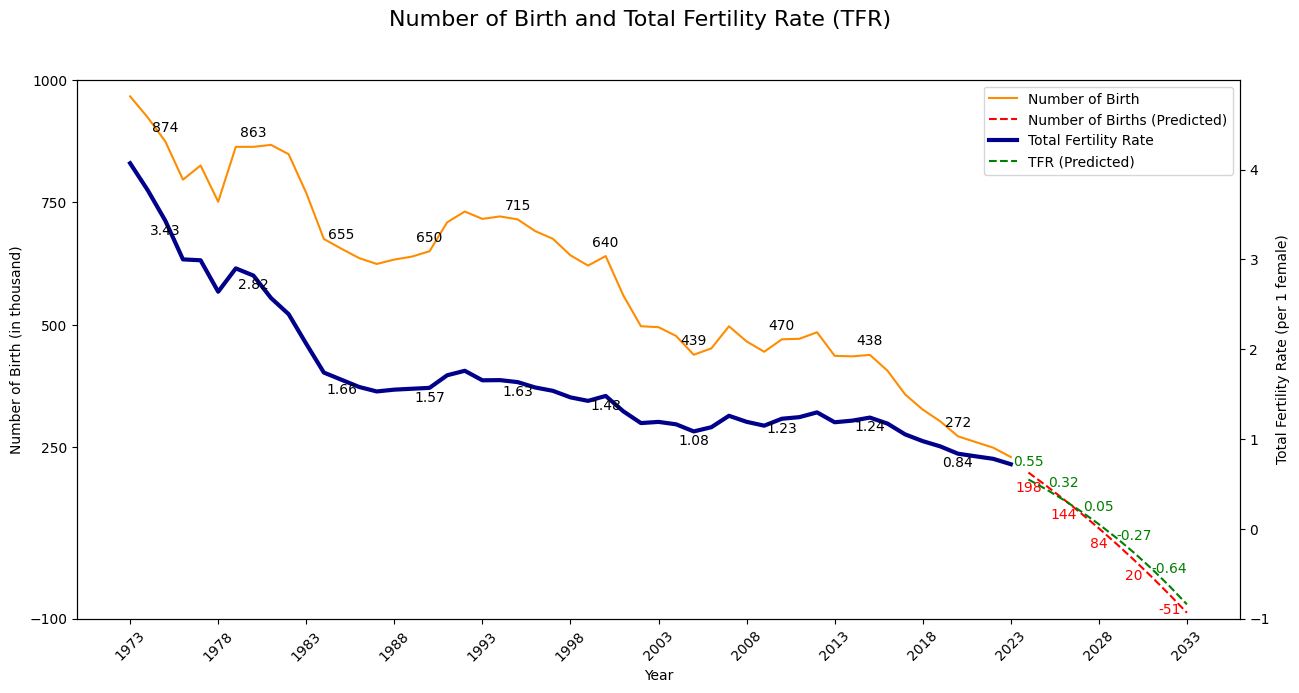

Polynomial Regression Model for Number of Births:
Mean Squared Error: 2763.055054026752
R-squared: 0.9231181734815048

Polynomial Regression Model for Total Fertility Rate:
Mean Squared Error: 0.023637505147792143
R-squared: 0.9603451244407863


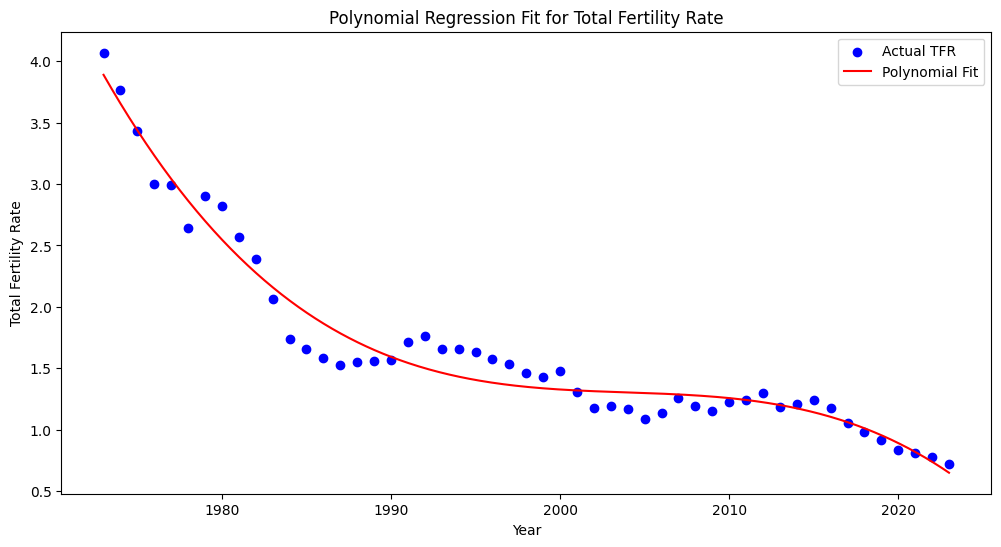

In [8]:
# Plotting
fig, ax1 = plt.subplots(figsize=(15, 7))
fig.suptitle('Number of Birth and Total Fertility Rate (TFR)', fontsize=16)

# Plot for Number of Birth
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Birth (in thousand)')
ax1.set_ylim(-100, 1000)
ax1.set_yticks([-100, 250, 500, 750, 1000])
ax1.plot(df.index, df['Number of Birth'], color='darkorange', label='Number of Birth')

# Annotations for Number of Birth
for x_val, y_val in zip(df.index, df['Number of Birth']):
    if x_val % 5 == 0:
        ax1.text(x_val, y_val + 20, f'{y_val:.0f}', ha='center')

# Twin axis for Total Fertility Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Total Fertility Rate (per 1 female)')
ax2.set_ylim(-1, 5)
ax2.set_yticks([-1, 0, 1, 2, 3, 4])
ax2.plot(df.index, df['Total Fertility Rate'], color='darkblue', lw=3, label='Total Fertility Rate')

# Annotations for Total Fertility Rate
for x_val, y_val in zip(df.index, df['Total Fertility Rate']):
    if x_val % 5 == 0:
        ax2.text(x_val, y_val - 0.15, f'{y_val:.2f}', ha='center')

# Set x-ticks to show every 5th year (adjust according to your data)
plt.xticks(df.index[::5])

# Predicted data plots (polynomial regression)
ax1.plot(future_years, predicted_births_poly, linestyle='--', color='red', label='Number of Births (Predicted)')
ax2.plot(future_years, predicted_tfr_poly, linestyle='--', color='green', label='TFR (Predicted)')

# Annotations for predicted values
for x_val, y_val in zip(future_years.flatten(), predicted_births_poly):
    if x_val % 2 == 0:
        ax1.text(x_val, y_val - 40, f'{y_val:.0f}', ha='center', color='red')

for x_val, y_val in zip(future_years.flatten(), predicted_tfr_poly):
    if x_val % 2 == 0:
        ax2.text(x_val, y_val + 0.15, f'{y_val:.2f}', ha='center', color='green')

# Combine historical and future years for x-axis
all_years = np.concatenate([df.index, future_years.flatten()])

# Determine x-ticks at 5-year intervals
x_ticks = np.arange(min(all_years), max(all_years) + 1, 5)

# Set x-ticks to show every year for better clarity
ax1.set_xticks(x_ticks)  # Adjust step size if needed
ax1.set_xticklabels([f'{int(year)}' for year in x_ticks], rotation=45)

# Combine lines and labels for the legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

# Show the plot
plt.show()

# Print performance metrics
print("Polynomial Regression Model for Number of Births:")
print(f"Mean Squared Error: {mean_squared_error(y_birth, model_birth_poly.predict(X_poly))}")
print(f"R-squared: {r2_score(y_birth, model_birth_poly.predict(X_poly))}")

print("\nPolynomial Regression Model for Total Fertility Rate:")
print(f"Mean Squared Error: {mean_squared_error(y_tfr, model_tfr_poly.predict(X_poly))}")
print(f"R-squared: {r2_score(y_tfr, model_tfr_poly.predict(X_poly))}")

# Plot Polynomial Fit for TFR
plt.figure(figsize=(12, 6))
plt.scatter(X, y_tfr, color='blue', label='Actual TFR')
X_range = np.linspace(min(X), max(X), 500).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
plt.plot(X_range, model_tfr_poly.predict(X_range_poly), color='red', label='Polynomial Fit')
plt.xlabel('Year')
plt.ylabel('Total Fertility Rate')
plt.title('Polynomial Regression Fit for Total Fertility Rate')
plt.legend()
plt.show()